# Data Ingestion and Cleaning

We load the reviews and metadata datasets for Health and Personal Care, clean them up and merge them into a single dataframe ready for the next steps.

In [1]:
import sys
sys.path.insert(0, "src")

# Importing libraries
import pandas as pd
import numpy as np

from mean_squared_terrors.config import (
    MIN_REVIEWS, CAP_PRODUCT_TOKENS, CAP_FEATURES_TOKENS,
    CAP_DESC_TOKENS, CAP_DETAILS_TOKENS, MIN_REVIEW_TOKENS,
    REVIEWS_PER_RATING, SEMANTIC_DETAIL_KEYS, FORM_KEYS,
)
from mean_squared_terrors.cleaning import (
    clean_text, flatten_to_text, extract_details_semantic,
    get_brand, build_product_text, select_balanced,
)

In [2]:
# Importing the two dataset provided by Deloitte
df_meta = pd.read_json("data/meta_Health_and_Personal_Care.json", lines=True) 
df_review = pd.read_json("data/Health_and_Personal_Care.json", lines=True)
# Printing the info about the two Dataset
print(f" Metadata loaded: {df_meta.shape[0]:,} rows × {df_meta.shape[1]} columns")
print(f"Reviews loaded:  {df_review.shape[0]:,} rows × {df_review.shape[1]} columns")

 Metadata loaded: 60,293 rows × 14 columns
Reviews loaded:  494,121 rows × 10 columns


In [3]:
# Checking the first rows of the two datasets
print("Metadata")
display(df_meta.head())
print("\nReviews")
display(df_review.head())

Metadata


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Health & Personal Care,Silicone Bath Body Brush Exfoliator Shower Bac...,3.9,7,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Rzoeox,[],{'Package Dimensions': '15 x 3.3 x 1.5 inches;...,B07V346GZH,NaN
1,Health & Personal Care,"iPhone 7 Plus 8 Plus Screen Protector, ZHXIN T...",3.8,2,[Tough and Robust: Like all 78X screen protect...,[Features: 2.5D Arc Edge Treatment: The edge i...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],ZHXIN,[],"{'Brand': 'ZHXIN', 'Compatible Devices': 'Cell...",B075W927RH,NaN
2,Health & Personal Care,Zig Zag Rolling Machine 70mm Size With FREE BO...,3.9,7,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],NaN,[],{'Package Dimensions': '4.1 x 1.8 x 0.3 inches...,B01FB26VKY,NaN
3,Health & Personal Care,Sting-Kill Disposable Wipes 8 Each ( Pack of 5),4.1,6,[],"[effective on stings and bites from bees, wasp...",21.37,[{'thumb': 'https://m.media-amazon.com/images/...,[],Sting-kill,[],"{'Brand': 'Sting-kill', 'Item Form': 'Wipe', '...",B01IAI29RU,NaN
4,Health & Personal Care,Heated Eyelash Curler Mini Portable Electric E...,3.3,8,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],BiBOSS,[],{'Package Dimensions': '6.1 x 3.1 x 1.9 inches...,B08CMN38RC,NaN



Reviews


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,4,12 mg is 12 on the periodic table people! Mg f...,This review is more to clarify someone else’s ...,[],B07TDSJZMR,B07TDSJZMR,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-06 00:49:35.902,3,True
1,5,Save the lanet using less plastic.,Love these easy multitasking bleach tablets. B...,[],B08637FWWF,B08637FWWF,AEVWAM3YWN5URJVJIZZ6XPD2MKIA,2020-11-02 22:03:06.880,3,True
2,5,Fantastic,I have been suffering a couple months with hee...,[],B07KJVGNN5,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2019-07-24 11:13:58.905,0,True
3,4,It holds the water and makes bubbles. That's ...,"It's cheap and it does what I wanted. The ""ma...",[],B007HY7GC2,B092RP73CX,AEZGPLOYTSAPR3DHZKKXEFPAXUAA,2022-09-04 02:29:02.725,7,True
4,1,Not for me,Didn't do a thing for me. Not saying they don'...,[],B08KYJLF5T,B08KYJLF5T,AEQAYV7RXZEBXMQIQPL6KCT2CFWQ,2022-01-20 23:53:07.262,0,True


In [4]:
# Checking the datatypes
print("Meta dtypes:\n", df_meta.dtypes)
print("\nReview dtypes:\n", df_review.dtypes)

Meta dtypes:
 main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store                  str
categories          object
details             object
parent_asin            str
bought_together    float64
dtype: object

Review dtypes:
 rating                        int64
title                           str
text                            str
images                       object
asin                            str
parent_asin                     str
user_id                         str
timestamp            datetime64[ms]
helpful_vote                  int64
verified_purchase              bool
dtype: object


In [5]:
# Missing values BEFORE converting empty lists/dicts/strings to NaN
meta_missing_raw = df_meta.isna().mean().sort_values(ascending=False)
review_missing_raw = df_review.isna().mean().sort_values(ascending=False)

print("Missing meta (raw):\n", meta_missing_raw.head(15))
print("\nMissing review (raw):\n", review_missing_raw.head(15))

Missing meta (raw):
 bought_together    1.000000
price              0.825253
store              0.038910
average_rating     0.000000
main_category      0.000000
title              0.000000
description        0.000000
features           0.000000
rating_number      0.000000
images             0.000000
videos             0.000000
categories         0.000000
details            0.000000
parent_asin        0.000000
dtype: float64

Missing review (raw):
 rating               0.0
title                0.0
text                 0.0
images               0.0
asin                 0.0
parent_asin          0.0
user_id              0.0
timestamp            0.0
helpful_vote         0.0
verified_purchase    0.0
dtype: float64


In [6]:
# Configuration imported from src/mean_squared_terrors/config.py
print("Configuration:")
print(f"  Products : min {MIN_REVIEWS} reviews, text cap {CAP_PRODUCT_TOKENS} tokens")
print(f"  Reviews  : min {MIN_REVIEW_TOKENS} tokens, balanced selection {REVIEWS_PER_RATING}")
print(f"  Max reviews/product: {sum(REVIEWS_PER_RATING.values())}")

Configuration:
  Products : min 10 reviews, text cap 300 tokens
  Reviews  : min 25 tokens, balanced selection {5: 5, 4: 3, 3: 2, 2: 3, 1: 3}
  Max reviews/product: 16


## Handling Hidden Missing Values

Some columns have empty lists, empty dicts or empty strings that pandas doesn't see as NaN, so we convert them all.

In [7]:
# Converting [], {}, and "" to NaN in both dataframes. Only object columns are checked

def _is_empty(val):
    if isinstance(val, (list, dict)):
        return len(val) == 0
    return val == ""

for col in df_meta.select_dtypes(include="object").columns:
    mask = df_meta[col].apply(_is_empty)
    df_meta.loc[mask, col] = np.nan

for col in df_review.select_dtypes(include="object").columns:
    mask = df_review[col].apply(_is_empty)
    df_review.loc[mask, col] = np.nan

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19844\889855345.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_meta.select_dtypes(include="object").columns:


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19844\889855345.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_review.select_dtypes(include="object").columns:


In [8]:
# Counting missing values AFTER cleanup
meta_missing = df_meta.isna().mean().sort_values(ascending=False)
review_missing = df_review.isna().mean().sort_values(ascending=False)

print("Meta missing ratio (clean):\n", meta_missing.head(20))
print("\nReview missing ratio (clean):\n", review_missing.head(20))

# Drop columns that are 100% NaN 
cols_all_nan = [col for col in df_meta.columns if df_meta[col].isna().all()]
print(f"\nDropping 100% NaN columns: {cols_all_nan}")
df_meta.drop(columns=cols_all_nan, inplace=True)

Meta missing ratio (clean):
 categories         1.000000
bought_together    1.000000
videos             0.863384
price              0.825253
features           0.740832
description        0.706765
store              0.038910
details            0.016403
title              0.000083
main_category      0.000000
average_rating     0.000000
rating_number      0.000000
images             0.000000
parent_asin        0.000000
dtype: float64

Review missing ratio (clean):
 images               0.956972
text                 0.000055
title                0.000000
rating               0.000000
asin                 0.000000
parent_asin          0.000000
user_id              0.000000
timestamp            0.000000
helpful_vote         0.000000
verified_purchase    0.000000
dtype: float64

Dropping 100% NaN columns: ['categories', 'bought_together']


## Filtering

We only keep verified purchases and products with more than 10 reviews to avoid spam and statistically meaningless data.

In [9]:
# Keeping only verified purchases
print(f"Reviews before verified filter: {len(df_review)}")
df_review = df_review[df_review["verified_purchase"]].copy()
print(f"Reviews after verified filter:  {len(df_review)}")

Reviews before verified filter: 494121


Reviews after verified filter:  445072


### Long-tail distribution

Amazon products follow a classic long-tail distribution: most products have 1-2 reviews while a minority concentrates the review mass. Filtering at `MIN_REVIEWS = 10` removes the long-tail (~86% of unique products) but preserves the bulk of the review signal (~73% of reviews retained).

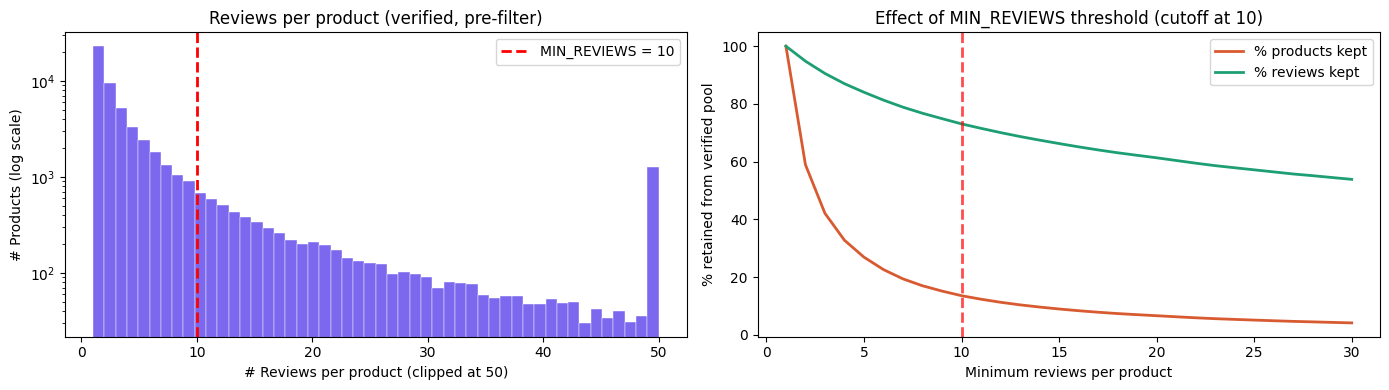

Verified products:                 56,306
Verified reviews:                  445,072
Products kept (>=10 reviews):       7,658 (13.6%)
Reviews kept:                      325,305 (73.1%)
-> 86% of products dropped, but only 27% of reviews lost


In [10]:
import matplotlib.pyplot as plt

# Distribution of review counts per product, in the verified-only state (pre MIN_REVIEWS filter)
review_counts = df_review.groupby("parent_asin").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: long-tail histogram with log-y axis
axes[0].hist(review_counts.clip(upper=50), bins=50, color="#7B68EE", edgecolor="white", linewidth=0.3)
axes[0].axvline(MIN_REVIEWS, color="red", ls="--", lw=2, label=f"MIN_REVIEWS = {MIN_REVIEWS}")
axes[0].set_yscale("log")
axes[0].set(title="Reviews per product (verified, pre-filter)",
            xlabel="# Reviews per product (clipped at 50)",
            ylabel="# Products (log scale)")
axes[0].legend()

# Panel 2: cumulative trade-off — products kept vs reviews kept at each threshold
thresholds = list(range(1, 31))
total_p = len(review_counts)
total_r = review_counts.sum()
pct_prod = [(review_counts >= t).sum() / total_p * 100 for t in thresholds]
pct_rev  = [review_counts[review_counts >= t].sum() / total_r * 100 for t in thresholds]

axes[1].plot(thresholds, pct_prod, color="#D85A30", lw=2, label="% products kept")
axes[1].plot(thresholds, pct_rev,  color="#1D9E75", lw=2, label="% reviews kept")
axes[1].axvline(MIN_REVIEWS, color="red", ls="--", lw=2, alpha=0.7)
axes[1].set(title=f"Effect of MIN_REVIEWS threshold (cutoff at {MIN_REVIEWS})",
            xlabel="Minimum reviews per product",
            ylabel="% retained from verified pool")
axes[1].legend()

plt.tight_layout()
plt.show()

# Numerical summary of the trade-off
n_prod_kept = (review_counts >= MIN_REVIEWS).sum()
n_rev_kept  = review_counts[review_counts >= MIN_REVIEWS].sum()
print(f"Verified products:                 {total_p:,}")
print(f"Verified reviews:                  {total_r:,}")
print(f"Products kept (>={MIN_REVIEWS} reviews):       {n_prod_kept:,} ({n_prod_kept/total_p:.1%})")
print(f"Reviews kept:                      {n_rev_kept:,} ({n_rev_kept/total_r:.1%})")
print(f"-> {(1 - n_prod_kept/total_p):.0%} of products dropped, but only {(1 - n_rev_kept/total_r):.0%} of reviews lost")

In [11]:
# Keeping only products with more than MIN_REVIEWS reviews (defined in config cell)
review_counts = df_review.groupby("parent_asin").size()
valid_asins = review_counts[review_counts >= MIN_REVIEWS].index

print(f"Unique products before filter: {df_review['parent_asin'].nunique()}")
df_review = df_review[df_review["parent_asin"].isin(valid_asins)].copy()
print(f"Unique products after filter (>={MIN_REVIEWS} reviews): {df_review['parent_asin'].nunique()}")
print(f"Total reviews kept: {len(df_review)}")

Unique products before filter: 56306


Unique products after filter (>=10 reviews): 7658
Total reviews kept: 325305


## Text Cleaning

We remove HTML tags, special characters and extra whitespace from review and metadata text.

New helper functions added:
**`clean_text`**: strips HTML, normalises apostrophes *and* unicode dashes (`–` `—` → `-`).
**`flatten_to_text`**: converts list or string to clean text with optional token cap.
**`extract_details_semantic`**: selects the 18+ semantically useful keys from `details` (Skin Type, Material, Flavor, etc.) and separates FORM fields (Item Form, Dosage Form) which go at the top of the product text to disambiguate category immediately (shampoo vs capsule vs cream vs device).
**`get_brand`**: extracts brand from multiple fallback sources: `brand` column, `store` column, `details` dict.

In [12]:
# Apply to review columns
df_review["title"] = df_review["title"].apply(clean_text)
df_review["text"]  = df_review["text"].apply(clean_text)

# Apply to metadata title (description_clean is cleaned later, after flatten_to_text)
df_meta["title"] = df_meta["title"].apply(clean_text)

df_review[["title", "text"]].head()

,title,text
0,12 mg is 12 on the periodic table people! Mg f...,This review is more to clarify someone else's ...
2,Fantastic,I have been suffering a couple months with hee...
3,It holds the water and makes bubbles. That's w...,It's cheap and it does what I wanted. The mass...
4,Not for me,Didn't do a thing for me. Not saying they don'...
17,returned,it was a nice tray smaller than i expected but...


## Merge Metadata and Reviews

We enrich the metadata with brand (multi-fallback), description, features, semantic details (with FORM fields separated to disambiguate product category), and merge with reviews on parent_asin.

In [13]:
# Build enriched metadata fields using the new helper functions
df_meta["brand"]             = df_meta.apply(lambda r: get_brand(r.to_dict()), axis=1)
df_meta["description_clean"] = df_meta["description"].apply(lambda x: flatten_to_text(x, cap_tokens=CAP_DESC_TOKENS))
df_meta["features_clean"]    = df_meta["features"].apply(lambda x: flatten_to_text(x, cap_tokens=CAP_FEATURES_TOKENS))

# Extract semantic details — form_text (Item Form/Dosage Form) goes at top of product text
form_details = df_meta["details"].apply(lambda x: extract_details_semantic(x, cap_tokens=CAP_DETAILS_TOKENS))
df_meta["form_text"]    = form_details.apply(lambda x: x[0])
df_meta["details_rest"] = form_details.apply(lambda x: x[1])

# description_clean exists only after flatten_to_text above, so it's cleaned here (title was cleaned earlier)
df_meta["description_clean"] = df_meta["description_clean"].apply(
    lambda x: clean_text(x) if pd.notna(x) else x
)

print(f"Brand coverage:       {df_meta['brand'].notna().mean():.2%}")
print(f"Description coverage: {df_meta['description_clean'].notna().mean():.2%}")
print(f"Features coverage:    {df_meta['features_clean'].notna().mean():.2%}")
print(f"Form coverage:        {df_meta['form_text'].notna().mean():.2%}")
print(f"Details coverage:     {df_meta['details_rest'].notna().mean():.2%}")

Brand coverage:       95.63%
Description coverage: 29.14%
Features coverage:    25.87%
Form coverage:        34.11%
Details coverage:     43.05%


In [14]:
# Selecting relevant metadata columns and merge with reviews
meta_cols = df_meta[[
    "parent_asin", "title", "brand", "description_clean", "features_clean",
    "form_text", "details_rest", "price", "store"
]].copy()

# Renaming to avoid column name clashes after merge
meta_cols.rename(columns={"title": "product_title"}, inplace=True)

# Merging on parent_asin (left join: keep all filtered reviews, attach metadata)
df = df_review.merge(meta_cols, on="parent_asin", how="left")

# Sanity check: every review must have a metadata match — otherwise product fields are NaN
orphan = df["product_title"].isna().sum()
print(f"Reviews with no meta match: {orphan:,} ({orphan/len(df):.2%})")

print(f"Merged dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Reviews with no meta match: 359 (0.11%)
Merged dataset shape: (325305, 18)
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'product_title', 'brand', 'description_clean', 'features_clean', 'form_text', 'details_rest', 'price', 'store']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_title,brand,description_clean,features_clean,form_text,details_rest,price,store
0,4,12 mg is 12 on the periodic table people! Mg f...,This review is more to clarify someone else's ...,NaN,B07TDSJZMR,B07TDSJZMR,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-06 00:49:35.902,3,True,High Potency Magnesium Citrate Capsules 1000mg...,Life Nutrition,NaN,NaN,NaN,Flavor: Unflavored. Product Benefits: Nutritional,NaN,Life Nutrition
1,5,Fantastic,I have been suffering a couple months with hee...,NaN,B07KJVGNN5,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2019-07-24 11:13:58.905,0,True,"Dr. Foot's Gel Heel Protectors, Plantar Fascii...",Dr.Foot,NaN,NaN,NaN,NaN,NaN,Dr.Foot
2,4,It holds the water and makes bubbles. That's w...,It's cheap and it does what I wanted. The mass...,NaN,B007HY7GC2,B092RP73CX,AEZGPLOYTSAPR3DHZKKXEFPAXUAA,2022-09-04 02:29:02.725,7,True,"Homedics Bubble Bliss Deluxe-Foot Spa, Heat Ma...",Homedics,NaN,Fizz your feet Active bubble massage soothes a...,Material: Plastic,Power Source: Corded Electric,NaN,Homedics
3,1,Not for me,Didn't do a thing for me. Not saying they don'...,NaN,B08KYJLF5T,B08KYJLF5T,AEQAYV7RXZEBXMQIQPL6KCT2CFWQ,2022-01-20 23:53:07.262,0,True,Brain Supplement 1053mg - Premium Nootropic Br...,Nature's Nutrition,NaN,NaN,Item Form: Capsule. Dosage Form: Capsule,NaN,NaN,Nature's Nutrition
4,5,returned,it was a nice tray smaller than i expected but...,NaN,B01H0SVP9O,B01H0SVP9O,AHGAOIZVODNHYMNCBV4DECZH42UQ,2020-11-11 14:54:54.192,0,True,North American Walker Tray with Non-Slip Grip Mat,North American Health Wellness,Walker tray with grip mat. Turn any walker int...,"Turn any walker into a TV tray, easily transfe...",NaN,NaN,26.9,North American Health + Wellness


## Deduplication

We remove duplicate reviews before building the product-level dataset and the balanced selection. Two passes:
1. Same user reviewing the same product more than once
2. Identical review text across different entries

In [15]:
# Remove duplicate reviews BEFORE product-level aggregation and balanced selection
n_before = len(df)
df = df.drop_duplicates(subset=["user_id", "parent_asin"])
df = df.drop_duplicates(subset=["text", "parent_asin"])  # same text for same product = spam
print(f"Before dedup: {n_before:,} reviews")
print(f"After dedup:  {len(df):,} reviews ({n_before - len(df):,} removed)")

Before dedup: 325,305 reviews
After dedup:  319,018 reviews (6,287 removed)


## Product Ratings from Dataset

We compute `product_avg_rating` and `product_rating_count` per product by aggregating the rating column of the deduplicated reviews in `df`. We do not use Amazon's `average_rating` and `rating_number` from the metadata because those values do not refer to the data the system actually analyses.

In [16]:
# Compute product-level avg rating + count from the deduplicated reviews
rating_agg = df.groupby("parent_asin").agg(
    product_avg_rating=("rating", "mean"),
    product_rating_count=("rating", "count"),
).reset_index()

df = df.merge(rating_agg, on="parent_asin", how="left")

print(f"Products with computed ratings: {rating_agg.shape[0]:,}")
print(f"  rating range: {rating_agg['product_avg_rating'].min():.2f} - {rating_agg['product_avg_rating'].max():.2f}")
print(f"  count range:  {rating_agg['product_rating_count'].min()} - {rating_agg['product_rating_count'].max()}")
rating_agg.head(3)

Products with computed ratings: 7,658
  rating range: 1.00 - 5.00
  count range:  8 - 2963


,parent_asin,product_avg_rating,product_rating_count
0,1465874399,4.462963,54
1,1930448732,4.312500,16
2,197480772X,4.863636,44


## Product-Level Dataset

We build a product-level table (one row per parent_asin) from the merged dataframe, combining title, brand and description into a single text field ready for embedding in the next step.

In [17]:
# Product-level table (1 row per parent_asin)
meta_unique_cols = [
    "parent_asin", "product_title", "brand", "description_clean", "features_clean",
    "form_text", "details_rest", "product_avg_rating", "product_rating_count", "price", "store"
]
meta_unique_cols = [c for c in meta_unique_cols if c in df.columns]

products_df = df[meta_unique_cols].drop_duplicates("parent_asin").copy()

products_df["product_text_base"] = products_df.apply(build_product_text, axis=1)
products_df["text_tokens"] = products_df["product_text_base"].str.split().str.len()

# Drop products with too-short text — embedding would be too noisy
n_before = len(products_df)
products_df = products_df[products_df["text_tokens"] >= 5].copy()
print(f"Dropped products with < 5 tokens: {n_before - len(products_df)} (kept {len(products_df)})")

# Keep df consistent: drop reviews of filtered products so reviews_cleaned.csv has the same ASIN set
n_rev_before = len(df)
df = df[df["parent_asin"].isin(products_df["parent_asin"])].reset_index(drop=True)
print(f"Dropped {n_rev_before - len(df):,} orphan reviews (kept {len(df):,})")

print("Products:", products_df.shape)
print(f"\nToken count per product (product_text_base):")
print(f"  mean={products_df['text_tokens'].mean():.0f}  "
      f"median={products_df['text_tokens'].median():.0f}  "
      f"min={products_df['text_tokens'].min()}  max={products_df['text_tokens'].max()}")
print(f"  < 20 tokens (poor text):  {(products_df['text_tokens'] < 20).mean():.1%}")
print(f"  > 100 tokens (rich text): {(products_df['text_tokens'] > 100).mean():.1%}")
products_df[["parent_asin", "product_text_base"]].head(3)

Dropped products with < 5 tokens: 11 (kept 7647)
Dropped 760 orphan reviews (kept 318,258)
Products: (7647, 13)

Token count per product (product_text_base):
  mean=75  median=38  min=5  max=300
  < 20 tokens (poor text):  13.7%
  > 100 tokens (rich text): 25.3%


,parent_asin,product_text_base
0,B07TDSJZMR,TITLE: High Potency Magnesium Citrate Capsules...
1,B07KJVGNN5,"TITLE: Dr. Foot's Gel Heel Protectors, Plantar..."
2,B092RP73CX,"TITLE: Homedics Bubble Bliss Deluxe-Foot Spa, ..."


## Review Selection — Balanced by Rating

Instead of picking the top-N reviews by helpful votes alone (which yields ~70% 5-star), we apply a **balanced selection** strategy:

| Rating | Cap | Reason |
|--------|-----|--------|
| 5★ | 5 | Most common — capped to reduce bias |
| 4★ | 3 | Positive with nuance |
| 3★ | 2 | Neutral, low signal — small cap |
| 2★ | 3 | Negative signal |
| 1★ | 3 | Critical signal — important for summaries |

Within each band, reviews are ranked by `helpful_vote` descending.

Reviews shorter than `MIN_REVIEW_TOKENS` tokens are excluded first to remove noise ("Love it!!", "Fast shipping", etc.).

In [18]:
review_cols = ["parent_asin", "title", "text", "rating", "verified_purchase", "helpful_vote", "timestamp"]
review_cols = [c for c in review_cols if c in df.columns]

reviews_df = df[review_cols].copy()
reviews_df["helpful_vote"] = reviews_df["helpful_vote"].fillna(0)
reviews_df["text"] = reviews_df["text"].fillna("").astype(str).str.strip()
reviews_df = reviews_df[reviews_df["text"].str.len() > 0]

# Filter out reviews that are too short — removes noise ("Love it!!", "Fast shipping", etc.)
reviews_df["tok_len"] = reviews_df["text"].str.split().str.len()
before_tok = len(reviews_df)
reviews_df = reviews_df[reviews_df["tok_len"] >= MIN_REVIEW_TOKENS].copy()
print(f"Reviews after min-token filter (>={MIN_REVIEW_TOKENS} tokens): {len(reviews_df):,}  "
      f"(removed {before_tok - len(reviews_df):,})")

# Balanced selection by rating — reduces 5-star bias from ~70% raw to ~48%
results = []
for _, grp in reviews_df.groupby("parent_asin"):
    results.append(select_balanced(grp))
reviews_top_df = pd.concat(results).reset_index(drop=True)

print(f"\nTop reviews (balanced selection): {reviews_top_df.shape}")
reviews_top_df.head(3)

Reviews after min-token filter (>=25 tokens): 130,786  (removed 186,634)



Top reviews (balanced selection): (57097, 8)


,parent_asin,title,text,rating,verified_purchase,helpful_vote,timestamp,tok_len
0,1465874399,Worked immediately,"I purchased these, recommended after a 7 day l...",5,True,23,2022-03-23 18:48:53.638,193
1,1465874399,YOU WANT THIS FOR BP CONTROL WITH LITTLE OR NO...,"Hubby had CHRONIC high BP for decades, in his ...",5,True,20,2022-09-01 23:16:50.328,190
2,1465874399,My blood pressure was checking around 135-140/...,My blood pressure was checking around 135-140/...,5,True,19,2015-01-01 23:40:40.000,59


In [19]:
counts = reviews_top_df.groupby("parent_asin").size()
print(f"Reviews per product — min: {counts.min()}  max: {counts.max()}  mean: {counts.mean():.1f}")
print(f"Products with < 5 reviews selected: {(counts < 5).sum()}")

# Rating distribution after balancing
print("\nRating distribution (after balanced selection):")
total = len(reviews_top_df)
for r in [1, 2, 3, 4, 5]:
    n   = (reviews_top_df["rating"] == r).sum()
    bar = '█' * int(n / total * 40)
    print(f"  {r}★ {bar:<40} {n:,} ({n/total:.1%})")

print(f"\nToken stats (reviews):")
print(f"  mean={reviews_top_df['tok_len'].mean():.0f}  "
      f"median={reviews_top_df['tok_len'].median():.0f}  "
      f"p90={reviews_top_df['tok_len'].quantile(0.9):.0f}")

Reviews per product — min: 1  max: 16  mean: 7.5
Products with < 5 reviews selected: 1899

Rating distribution (after balanced selection):
  1★ ██████                                   9,363 (16.4%)
  2★ ████                                     6,130 (10.7%)
  3★ ████                                     6,098 (10.7%)
  4★ ██████                                   9,140 (16.0%)
  5★ ██████████████████                       26,366 (46.2%)

Token stats (reviews):
  mean=67  median=48  p90=122


## Product Images

We extract the main image URL for every product kept in `products_df` from the `images` field already loaded in `df_meta`.
For each product we prefer the `MAIN` variant (`large` → `hi_res` → `thumb`), otherwise we fall back to the first image available.
The resulting map is saved to `data/product_images.csv` and is consumed by the demo notebook (`06_Demo.ipynb`) and the FastAPI webapp (`webapp/server.py`).

In [20]:
# Build product image map from df_meta, restricted to products kept after filtering
asins_kept = set(products_df["parent_asin"])
img_rows = []
for asin, imgs in df_meta[["parent_asin", "images"]].itertuples(index=False):
    if asin not in asins_kept or not isinstance(imgs, list) or not imgs:
        continue
    url = None
    for img in imgs:
        if isinstance(img, dict) and img.get("variant") == "MAIN":
            url = img.get("large") or img.get("hi_res") or img.get("thumb")
            break
    if url is None:
        first = imgs[0]
        if isinstance(first, dict):
            url = first.get("large") or first.get("hi_res") or first.get("thumb")
    if url:
        img_rows.append({"parent_asin": asin, "image_url": url})

product_images_df = pd.DataFrame(img_rows)
print(f"Image URLs extracted: {len(product_images_df):,} / {len(asins_kept):,} products")
product_images_df.head(3)

Image URLs extracted: 7,647 / 7,647 products


,parent_asin,image_url
0,B07FTJBJWK,https://m.media-amazon.com/images/I/41EKp38hWd...
1,B07VXRM7H9,https://m.media-amazon.com/images/I/51llAX-MfG...
2,B07FKD6J76,https://m.media-amazon.com/images/I/41uwm1IuvF...


## Data Quality Validation

Final validation before persisting the cleaned dataset: missing values across key columns, rating range and distribution, and empty text count. Any anomaly here points back to an upstream cleaning or merge issue.

In [21]:
# Missing values in key columns
key_cols = ["rating", "text", "parent_asin", "product_title", "brand", "price"]
missing_pct = df[key_cols].isna().mean().sort_values(ascending=False)
print("Missing % in key columns:")
print(missing_pct)

# Rating sanity check
print(f"\nRating range: {df['rating'].min()} – {df['rating'].max()}")
print(f"Rating value counts:\n{df['rating'].value_counts().sort_index()}")

# Empty text check
empty_text = (df["text"].fillna("").astype(str).str.strip().str.len() == 0).sum()
print(f"\nEmpty text fields: {empty_text:,}")

Missing % in key columns:
price            0.577296
brand            0.022482
text             0.002633
product_title    0.000211
rating           0.000000
parent_asin      0.000000
dtype: float64

Rating range: 1 – 5
Rating value counts:
rating
1     43963
2     18842
3     23547
4     35584
5    196322
Name: count, dtype: int64



Empty text fields: 838


In [22]:
# Saving the cleaned and merged datasets for the next steps
df.to_csv("data/reviews_cleaned.csv", index=False)
products_df.to_csv("data/products_cleaned.csv", index=False)
reviews_top_df.to_csv("data/reviews_topN.csv", index=False)
product_images_df.to_csv("data/product_images.csv", index=False)

print("Saved: data/reviews_cleaned.csv")
print("Saved: data/products_cleaned.csv")
print("Saved: data/reviews_topN.csv")
print("Saved: data/product_images.csv")

Saved: data/reviews_cleaned.csv
Saved: data/products_cleaned.csv
Saved: data/reviews_topN.csv
Saved: data/product_images.csv
